# Heart Disease Prediction - Decision Tree

**Problem Statement:** Predict whether a patient has heart disease (1) or not (0)
using their medical measurements (age, cholesterol, blood pressure, etc).

We use a **Decision Tree Classifier** to keep things simple and easy to understand.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load Dataset

In [2]:
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3. EDA (Exploratory Data Analysis)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

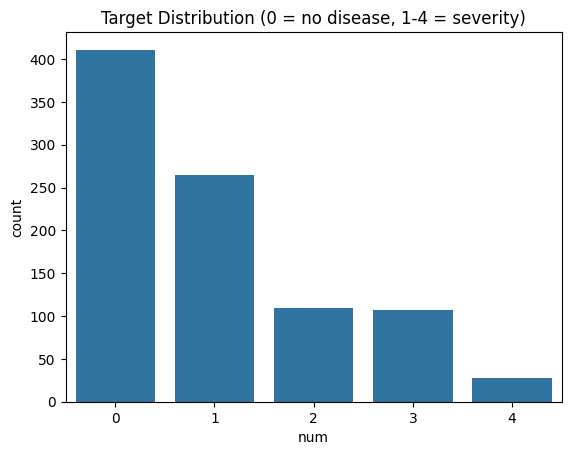

In [6]:
sns.countplot(x="num", data=df)
plt.title("Target Distribution (0 = no disease, 1-4 = severity)")
plt.show()

## 4. Cleaning
Drop columns that are not useful for prediction.

In [7]:
df = df.drop(columns=["id", "dataset"])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 5. Missing Values
Fill numeric columns with median, categorical columns with mode (most frequent value).

In [8]:
numeric_cols = ["trestbps", "chol", "thalch", "oldpeak", "ca"]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = ["fbs", "restecg", "exang", "slope", "thal"]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

## 6. Outliers
Cap extreme values using the IQR method (instead of deleting rows).

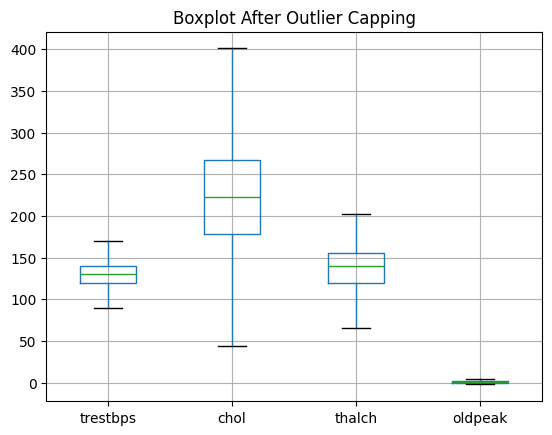

In [9]:
outlier_cols = ["trestbps", "chol", "thalch", "oldpeak"]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

df[outlier_cols].boxplot()
plt.title("Boxplot After Outlier Capping")
plt.show()

## 7. Feature Engineering
Convert the 5-class target (0-4) into a simple binary target: 0 = no disease, 1 = disease.

In [10]:
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])

df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

## 8. Encoding
Convert text columns into numbers so the model can use them.

In [11]:
df["fbs"] = df["fbs"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})
df["exang"] = df["exang"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})

label_cols = ["sex", "cp", "restecg", "slope", "thal"]
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

df.dtypes

age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal          int64
target        int64
dtype: object

## 9. Scaling
Decision Trees don't need scaling (they split on raw values), so we skip this step.

## 10. Train/Test Split

In [12]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (736, 13)
Test size: (184, 13)


## 11. Train Model (Decision Tree)

In [13]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Base Accuracy:", accuracy_score(y_test, preds))

Base Accuracy: 0.7391304347826086


## 12. Hyperparameter Tuning

In [14]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_model = grid.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV Accuracy: 0.7608751608751609


## 13. Cross Validation

In [15]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="accuracy")
print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Scores: [0.7173913  0.75543478 0.82065217 0.56521739 0.61413043]
Mean CV Accuracy: 0.6945652173913043


## 14. Evaluation

Test Accuracy: 0.8043478260869565

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.87      0.80        82
           1       0.88      0.75      0.81       102

    accuracy                           0.80       184
   macro avg       0.81      0.81      0.80       184
weighted avg       0.81      0.80      0.80       184



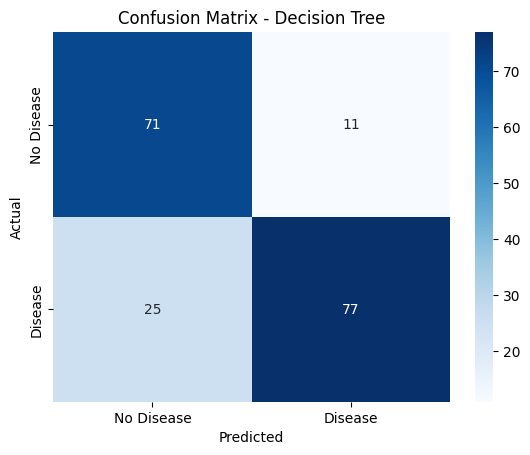

In [16]:
final_preds = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, final_preds))
print("\nClassification Report:\n", classification_report(y_test, final_preds))

cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## 15. Feature Importance

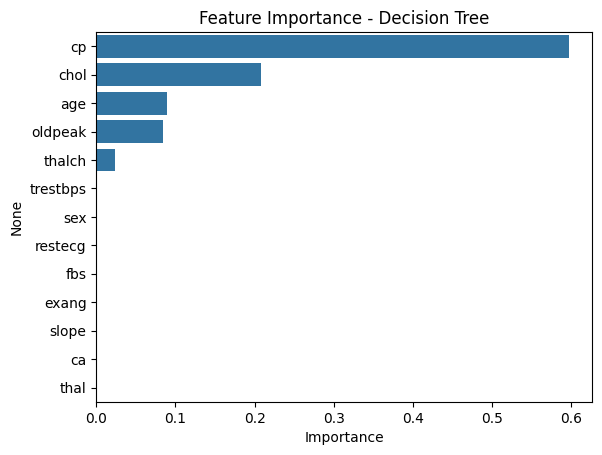

cp          0.596441
chol        0.207412
age         0.089129
oldpeak     0.083810
thalch      0.023209
trestbps    0.000000
sex         0.000000
restecg     0.000000
fbs         0.000000
exang       0.000000
slope       0.000000
ca          0.000000
thal        0.000000
dtype: float64

In [17]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.show()

importance

## 16. Visualize the Tree (Bonus)

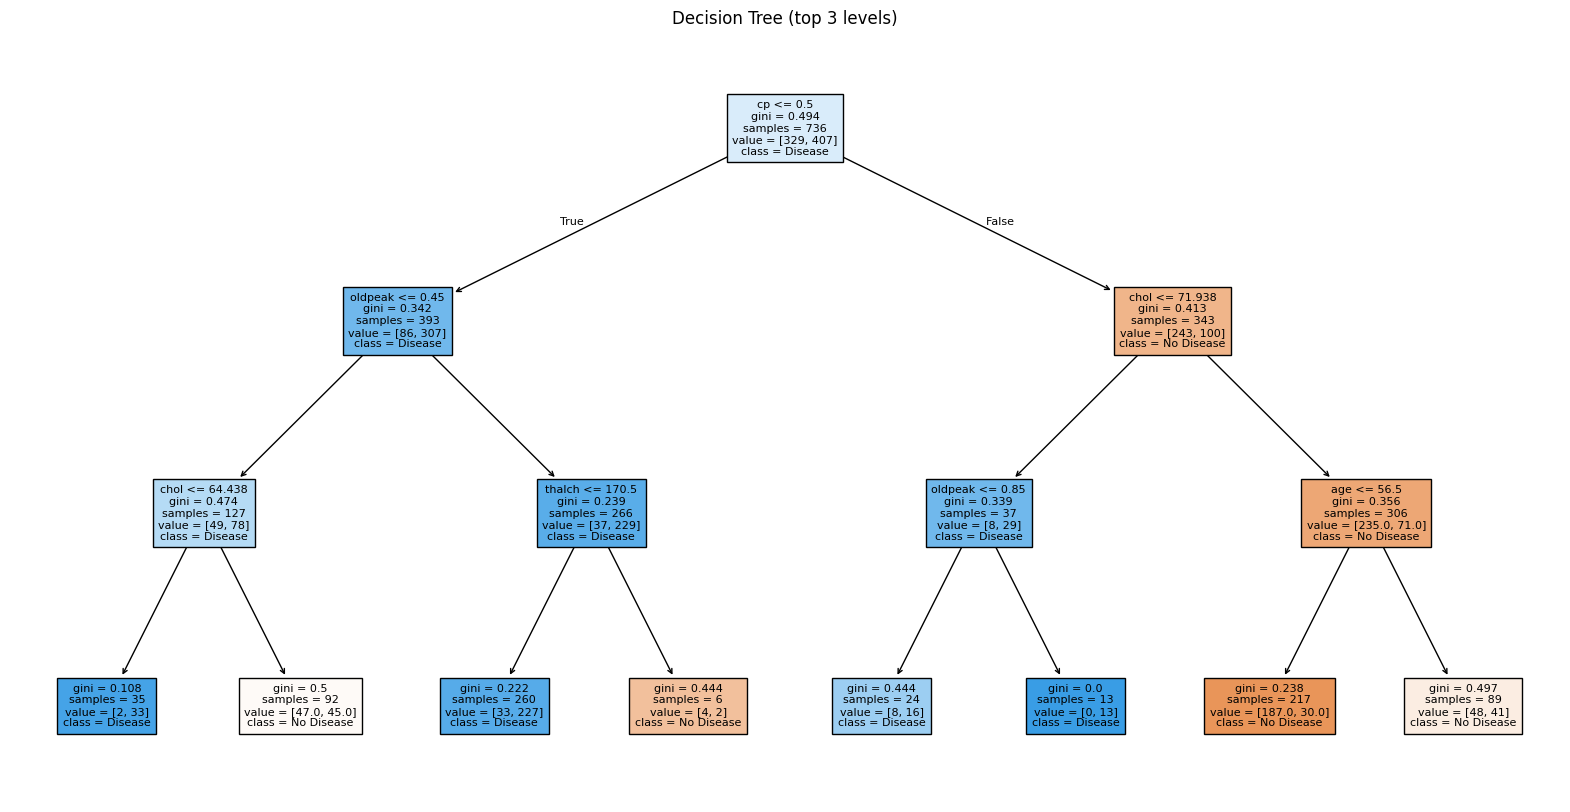

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=X.columns, class_names=["No Disease", "Disease"],
          filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree (top 3 levels)")
plt.show()

## 17. Conclusion

- We built a **Decision Tree Classifier** to predict heart disease.
- Cleaned missing values, capped outliers, encoded categorical columns.
- Tuned the tree using GridSearchCV (max_depth, min_samples_split, criterion).
- Evaluated using accuracy, classification report, confusion matrix, and cross validation.
- Checked feature importance to see which health measurements matter most.

Print the final test accuracy, mean CV accuracy, and top feature from the cells above
to fill in your own summary.